# Model Training

Building and compare different classification models

In [1]:
# some imports 
import pickle

In [ ]:
# loading data

with open("/Users/andrejartuschenko/Desktop/mailharpoon/backend/data/processed/preprocessed_data.pkl", "rb") as f:
    data = pickle.load(f)

X_train_full = data["X_train_full"]
X_test_full = data["X_test_full"]
X_train_url = data["X_train_url"]
X_test_url = data["X_test_url"]
y_train = data["y_train"]
y_test = data["y_test"]

In [4]:
print(X_train_full.shape, X_train_url.shape)
print(y_train.value_counts(normalize=True))

(8844, 30) (8844, 8)
result_bin
0    0.556988
1    0.443012
Name: proportion, dtype: float64


### Model Building Logistic Regression

In [8]:
# some imports for logisitic regression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


## Model Logistic Regression with all Features

In [6]:
log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

In [7]:
log_model.fit(X_train_full, y_train)
pred = log_model.predict(X_test_full)

In [9]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))


Confusion Matrix:
[[1169   62]
 [  97  883]]


In [10]:
print("\nClassification Report:")
print(classification_report(y_test, pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.94      1231
           1       0.93      0.90      0.92       980

    accuracy                           0.93      2211
   macro avg       0.93      0.93      0.93      2211
weighted avg       0.93      0.93      0.93      2211



In [11]:
# ROC-AUC
probs = log_model.predict_proba(X_test_full)[:, 1]
print("\nROC-AUC:", roc_auc_score(y_test, probs))


ROC-AUC: 0.9785034566222915


### Model Performance Overview Logistic regression with all features

**Accuracy:** 0.93  
**ROC-AUC:** 0.979  

**Precision:** 0.93  
**Recall:** 0.90  
**F1-score:** 0.92 

Meaning: 
- 90% of phishing webistes were correctly identified
- 10% of phishing websites werde missed (false negatives).
- when the model predict phishing, it is correct 93% of the time.

- The high ROC-AUC (0.979) indicates excellent class separability.
- The dataset appears to be largely linearly separable.
- Even a linear model performs very strongly, suggesting that the engineered features contain strong predictive signals.
- This establishes a strong baseline before testing more complex models.


## Model Logisitic Regression with URL-only

In [12]:
log_model.fit(X_train_url, y_train)
pred_url = log_model.predict(X_test_url)

In [13]:
print("\nConfusion Matrix (URL-only):")
print(confusion_matrix(y_test, pred_url))


Confusion Matrix (URL-only):
[[935 296]
 [345 635]]


In [14]:
print("\nClassification Report (URL-only):")
print(classification_report(y_test, pred_url))


Classification Report (URL-only):
              precision    recall  f1-score   support

           0       0.73      0.76      0.74      1231
           1       0.68      0.65      0.66       980

    accuracy                           0.71      2211
   macro avg       0.71      0.70      0.70      2211
weighted avg       0.71      0.71      0.71      2211



In [15]:
probs_url = log_model.predict_proba(X_test_url)[:, 1]
print("\nROC-AUC (URL-only):", roc_auc_score(y_test, probs_url))


ROC-AUC (URL-only): 0.7829639085528606


## Comparison: Full Feature Set vs URL-Only Features

URL-only features, performance dropped significantly:

Accuracy: 0.71
F1-score (Phishing): 0.66
Recall (Phishing): 0.65
ROC-AUC: 0.78

**Interpretation**

The substantial decline in performance indicates that URL structure alone is not sufficient to reliably detect phishing websites in this dataset.
In particular, the recall for phishing (0.65) suggests that a large number of phishing URLs are incorrectly classified as legitimate. This would be problematic in a real-world deployment, where missing phishing attacks poses a serious security risk.

The removed features (e.g., SSL state, domain registration length, traffic-based indicators) appear to contribute significantly to the model’s discriminative power.

**Conclusion**

While a URL-only approach simplifies deployment and avoids external lookups, it comes at the cost of substantially reduced predictive performance. A hybrid or enriched feature approach is likely necessary for robust phishing detection.

# Random Forrest - Full Feature Set

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [17]:
rf_full = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_full.fit(X_train_full, y_train)

pred_rf_full = rf_full.predict(X_test_full)
probs_rf_full = rf_full.predict_proba(X_test_full)[:, 1]

In [18]:
print("\nConfusion Matrix (RF Full):")
print(confusion_matrix(y_test, pred_rf_full))

print("\nClassification Report (RF Full):")
print(classification_report(y_test, pred_rf_full))

print("\nROC-AUC (RF Full):", roc_auc_score(y_test, probs_rf_full))


Confusion Matrix (RF Full):
[[1212   19]
 [  33  947]]

Classification Report (RF Full):
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1231
           1       0.98      0.97      0.97       980

    accuracy                           0.98      2211
   macro avg       0.98      0.98      0.98      2211
weighted avg       0.98      0.98      0.98      2211


ROC-AUC (RF Full): 0.9966515525787895


# Random Forest URL-Only

In [19]:
rf_url = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_url.fit(X_train_url, y_train)

pred_rf_url = rf_url.predict(X_test_url)
probs_rf_url = rf_url.predict_proba(X_test_url)[:, 1]

In [20]:
print("\nConfusion Matrix (RF URL-only):")
print(confusion_matrix(y_test, pred_rf_url))

print("\nClassification Report (RF URL-only):")
print(classification_report(y_test, pred_rf_url))

print("\nROC-AUC (RF URL-only):", roc_auc_score(y_test, probs_rf_url))


Confusion Matrix (RF URL-only):
[[860 371]
 [218 762]]

Classification Report (RF URL-only):
              precision    recall  f1-score   support

           0       0.80      0.70      0.74      1231
           1       0.67      0.78      0.72       980

    accuracy                           0.73      2211
   macro avg       0.74      0.74      0.73      2211
weighted avg       0.74      0.73      0.73      2211


ROC-AUC (RF URL-only): 0.8275493625557453


## Feature importance Plot

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importances extrahieren
importances = rf_full.feature_importances_

# In DataFrame packen
feat_importance = pd.DataFrame({
    "feature": X_train_full.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feat_importance.head(15)

,feature,importance
7,sslfinal_state,0.321124
13,url_of_anchor,0.256848
25,web_traffic,0.071184
6,having_sub_domain,0.061351
14,links_in_tags,0.042376
5,prefix_suffix,0.040908
15,sfh,0.020119
12,request_url,0.018942
28,links_pointing_to_page,0.018769
8,domain_registeration_length,0.016994


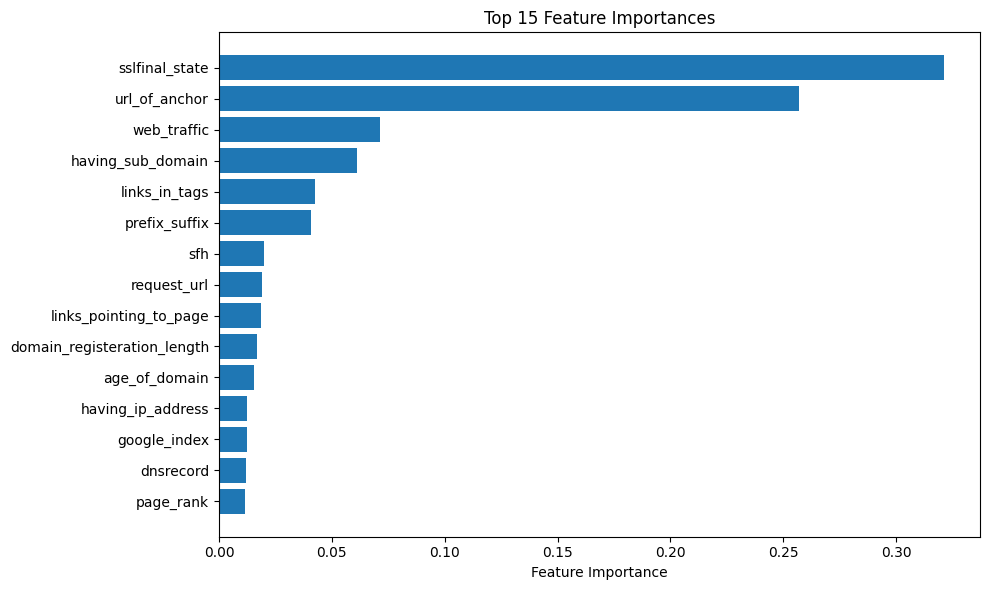

In [23]:
# top 15 features 

plt.figure(figsize=(10,6))
plt.barh(
    feat_importance["feature"].head(15)[::-1],
    feat_importance["importance"].head(15)[::-1]
)
plt.xlabel("Feature Importance")
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()

In [24]:
feat_importance["importance"].describe()

count    30.000000
mean      0.033333
std       0.072074
min       0.001433
25%       0.004730
50%       0.010116
75%       0.018899
max       0.321124
Name: importance, dtype: float64

### Feature Insights 

**sslfinal_state** carries 32% of the toal decision information. This also explains why the models perform significantly worse with the URL-only dataset.
We have two features that dominate the model. This is a very unevenly distributed feature importance.
Our models basically learn: if SSL is "bad", then phishing.



# Model definition and comparison on full data set

In [26]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

In [29]:
# models as dict

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(probability=True))
    ]),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(max_iter=2000, random_state=42))
    ]),
}


In [30]:
# cross validation setup

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "f1": "f1",
    "recall": "recall",
    "roc_auc": "roc_auc"
}

In [31]:
results = []

for name, model in models.items():
    print(f"Training {name}...")
    
    scores = cross_validate(
        model,
        X_train_full,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    
    results.append({
        "Model": name,
        "Accuracy": np.mean(scores["test_accuracy"]),
        "F1 (Phishing)": np.mean(scores["test_f1"]),
        "Recall (Phishing)": np.mean(scores["test_recall"]),
        "ROC-AUC": np.mean(scores["test_roc_auc"])
    })

results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
results_df

Training Logistic Regression...
Training KNN...
Training SVM...
Training Naive Bayes...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training MLP...


,Model,Accuracy,F1 (Phishing),Recall (Phishing),ROC-AUC
7,MLP,0.963931,0.958995,0.952014,0.994863
5,Random Forest,0.969471,0.965384,0.960947,0.994527
6,Gradient Boosting,0.948666,0.941540,0.933128,0.989911
2,SVM,0.947196,0.939384,0.923686,0.986960
1,KNN,0.937585,0.929158,0.923939,0.980363
0,Logistic Regression,0.928200,0.917969,0.906841,0.978716
3,Naive Bayes,0.600860,0.689124,0.998469,0.967420
4,Decision Tree,0.956242,0.950268,0.943337,0.967192
